# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

1) $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;

In [2]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "sympy"])


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


0

In [3]:
import sympy as sp

x1, x2 = sp.symbols("x1 x2", real=True)
f = x1**2 - x2                       

H = sp.hessian(f, (x1, x2))
print(H)                             
print(H.eigenvals())                 

Matrix([[2, 0], [0, 0]])
{2: 1, 0: 1}


**Вывод**: собственные числа Гессиана неотрицательны, значит функция выпукла по **критерию второго порядка**

2) $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;


**Вывод:**  Функция $g(x)=\|Ax-b\|_2$ — композиция выпуклой функции
$u|u\|_2$ (нормы) с аффинным отображением $Ax-b$, поэтому она
выпукла. 

Множество $\{g\le1\}$ — её подуровневое
множество, значит, оно выпукло при любых $A,b$.

3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$

In [4]:
x1, x2 = sp.symbols('x1 x2', real=True)

f = sp.Integer(1) - sp.sqrt(x1**2 + x2**2)

H = sp.hessian(f, (x1, x2))
#print(H)
print(H.eigenvals())

{-1/sqrt(x1**2 + x2**2): 1, 0: 1}


**Вывод:** функция не выпукла это догазывает  отрицательная полуопределеность Гессиана ($-\frac{1}{\sqrt{x_1^2 + x_2^2}}$ < 0 дробь всегда положительна, но минус делает её всегда отрицательной для любых x неравных 0)

**Ответ:** 
1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$ — **Выпукло**.

2. $\{x \in \mathbb{R}^n : \|Ax - b\|_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}, b \in \mathbb{R}^m$ — **Выпукло**.
   
3. $\{x \in \mathbb{R}^2 : \|x\|_2 \ge 1\}$ — **Невыпукло**.

**(б)**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.

In [5]:
# ваш код
x1, x2, a = sp.symbols("x1 x2 a", real=True)
f = x1**2 + a*x1*x2 + x2**2

H = sp.hessian(f, (x1, x2))
print(H)

leading_minors = [H[:i, :i].det() for i in range(1, H.shape[0] + 1)]

for idx, minor in enumerate(leading_minors, 1):
    print(f"Ведущий главный минор Δ_{idx} = {minor}")

Matrix([[2, a], [a, 2]])
Ведущий главный минор Δ_1 = 2
Ведущий главный минор Δ_2 = 4 - a**2


Чтобы функция была строго выпукла и соответсвенно матрица Гессе положительно определена, необходимо чтобы все главные миноры матрицы были строго больше нуля (критерий Сильвестра).

Δ_1 = 2 – всегда положительный

Δ_2 = $4 - a^2$ – положительный при $a^2 < 4$ --> $a \in (-2, 2)$, 
отрицательные при $a \in (-\infty, -2) \cup (2, +\infty)$



**Вывод:**
1. Функция **строго выпукла**, когда все ведущие миноры строго больше нуля:
   $$\Delta_2 > 0 \implies 4 - a^2 > 0 \implies a^2 < 4 \implies a \in (-2, 2)$$
2. Функция **выпукла** (нестрого), когда все главные миноры неотрицательны:
   $$\Delta_2 \ge 0 \implies 4 - a^2 \ge 0 \implies a^2 \le 4 \implies a \in [-2, 2]$$


In [6]:
# проверка значений через `np.linalg.eigvalsh`

import numpy as np

def get_hessian(a):
    return np.array([[2.0, float(a)], 
                     [float(a), 2.0]])

a_inside = 1
eig_inside = np.linalg.eigvalsh(get_hessian(a_inside))
print(eig_inside)


a_boundary = 2
eig_boundary = np.linalg.eigvalsh(get_hessian(a_boundary))
print(eig_boundary)

a_outside = 3
eig_outside = np.linalg.eigvalsh(get_hessian(a_outside))
print(eig_outside)


[1. 3.]
[0. 4.]
[-1.  5.]


Как видно по собственным значениям матриц Гессианов, в которые подставила значения 1, 2 и 3, в первом случае матрица положительна определена (функция выпукла строго), во втором положительна полуопределена (функция выпукла нестрого), в третьем матрица отрицательно определена (функция невыпукла), что и требовалось доказать.

2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$

Проверим через критерий второго порядка: найдем гессиан

In [7]:
x1, x2 = sp.symbols("x1 x2", real=True)
f = x1**2 * x2**2

H = sp.hessian(f, (x1, x2))
print(H)
#print(H.eigenvals())

delta_1 = H[0, 0]
print(delta_1)          
delta_2 = sp.simplify(H.det())
print(delta_2)

Matrix([[2*x2**2, 4*x1*x2], [4*x1*x2, 2*x1**2]])
2*x2**2
-12*x1**2*x2**2


Первый главный минор ($2*x_2^2$) всегда положительный

Второй главный минор ($-12x_1^2x_2^2$) всегда отрицательный

Следовательно матрица отрицательно определена и функци невыпукла.

**Ответ:** 

1) Функция **строго выпукла** при $a \in (-2, 2)$

   Функция **выпукла** (нестрого) при $a \in [-2, 2]$

2) Функция **невыпукла**

**(в)**

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;

Разберем функцию на компененты:

$\Vert Ax - b\Vert_2$ – композиция с аффинным отображением (пункт 2 в лекции 2 раздел 5): норма(выпуклая) и аффинное отображение, значит вся функция выпуклая

$\Vert x\Vert_\infty$ – норма(выпуклая) 

$\Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$ – все вместе является неотрицательной взвешенной суммой, коэффициент $\lambda$ > 0.

Следовательно функция выпуклая

Не гладкая: $\|Ax-b\|_2$ недифференцируема при $Ax=b$, $\|x\|_\infty$ —
   при совпадении модулей нескольких координат.

2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$

Разберем функцию на три компоненты:

$u$ = $a_i^\top x - b_i$ – аффинная функция выпуклая и невыпуклая одновременно

$u^2$ – график функции представляет собой пораболу, порабола ялвяется выпуклой функцией, тк хорда всегда расположена строго выше графика

$\max_{i} \big(a_i^\top x - b_i\big)^2$ – поточечный максимум выпуклах функций (пункт 3 лекции 2 раздел 5)

следовательно функция выпукла



Не гладкая: в точках, где максимум $(a_i^\top x-b_i)^2$ достигается
   одновременно при нескольких $i$, функция имеет излом.

3. $f(x) = e^{-\Vert x\Vert_2^2}$

Аналогичным образом рассматрим компоненты:

Композиция двух функций:

$e^{u}$ – выпуклая и неубывающая функция

$u = -\Vert x\Vert_2^2$ – хоть норма и выпукла, но отрицательная норма говорит о вогнутости, так что функция невыпукла

Данное протеворечит пункту 4 лекции 2 разделу 5, поэтому воспользоваться операциями, сохраняющими выпуклось для доказательства мы не можем

Контрпример: $x=(1,0)$, $y=(-1,0)$.
Тогда $f(x)=f(y)=e^{-1}\approx0.368$, но в середине отрезка $z=(0,0)$:
$f(z)=e^0=1 > \tfrac12f(x)+\tfrac12f(y)=e^{-1}$ — хорда проходит ниже графика,
что нарушает определение выпуклости.

Гладкая ($C^\infty$): $\|x\|_2^2$ — многочлен без излома в нуле,
   композиция с $e^{(\cdot)}$ бесконечно дифференцируема.

**(г)**

**Задача а.**

Цель: $\tfrac12∥x−p∥^2$ – аффинна

Равенства: $ g_1(x) = x_1 + x_2 + x_3 - 1 = 0$,  $g_2(x) = x_1 - x_3 = 0$ – аффинные

Неравенств нет. Условия выполнены, строго выпуклая

**Задача б.**

Цель: $f(x) = \sum_{j=1}^{n} c_j x_j = c^\top x$ – аффинна

Равенства: нет

Неравенства: $\sum A_{ij}x_i \ge b_i$, т.е $Ax - b \ge 0$ , $-Ax \le -b$ – аффинные

Условия выполнены, выпуклая (LP)

**Задача в.**

Цель: $-4x_1x_2$, через $Q=\begin{pmatrix}0&-4\\-4&0\end{pmatrix}$, собственные числа $\pm4$ — не выпукла

Равенства: $g(x)=x_1^2+x_2^2-1=0$ — нелинейное, не аффинное

Оба условия нарушены, невыпуклая задача

**Задача г.**

Цель: $f(x)=\tfrac12\|r(x)\|^2$, $r_i(x)=x_1\sin(x_2t_i+x_3)-y_i$ нелинейна по $x_2,x_3$ — не квадратичная форма, не композиция с аффинным

Ограничений нет

Условие на цель нарушено, невыпуклая задача

**Задача д (бонус).**

Цель: $t$ — аффинна

Неравенства: $h_i(x,t)=t-(a_i^\top x-b_i)\ge0$, $\tilde h_i(x,t)=t+(a_i^\top x-b_i)\ge0$ — аффинные (вогнутые)

Условия выполнены, выпуклая (LP)

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [8]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Задача 2(а).**

**1** 

Если $x^*$ лежит строго внутри $\Omega$, есть запас — можно сдвинуться в сторону
$p$, не выходя из $\Omega$, и уменьшить расстояние. Значит, $x^*$ не оптимальна.
Поэтому $x^*$ обязана лежать на границе: $a^\top x^*=b$.

**2**

 Для любого $v$ с $a^\top v=0$ точки $x^*\pm v$
лежат на той же границе $a^\top x=b$, значит допустимы. Подставляя обе в условие
оптимальности, получаем $(x^*-p)^\top v=0$ для всех таких $v$. Значит
$x^*-p$ ортогонален всей гиперплоскости $\{v:a^\top v=0\}$, а значит
коллинеарен нормали $a$:
$x^*=p+\lambda a.$

**3** 

Подставляем в $a^\top x^*=b$:
$a^\top p+\lambda\|a\|^2=b\ \Longrightarrow\ \lambda=-\frac{a^\top p-b}{\|a\|^2}.$

Отсюда
$x^*=p-\frac{a^\top p-b}{\|a\|^2}\,a.$

**4**

 Обозначим $t=\dfrac{a^\top p-b}{\|a\|^2}>0$
(так как $p\notin\Omega$). Тогда $x^*-p=-t\,a$, и для любого $y\in\Omega$:
$(x^*-p)^\top(y-x^*)=-t\,a^\top(y-x^*)=-t\big(a^\top y-b\big)=t\big(b-a^\top y\big)\ge0,$
поскольку $a^\top y\le b$ и $t>0$. Условие оптимальности выполнено для всех
$y\in\Omega$, значит по теореме раздела 7 найденная $x^*$ — решение задачи.

**Численная проверка (пункты 2 и 3)**

In [9]:
#пункт 2

from scipy.optimize import minimize

f = lambda x: 0.5 * np.sum((x - p) ** 2)
grad_f = lambda x: x - p

constraint = {"type": "ineq", "fun": lambda x: b - a @ x}

res = minimize(f, x0=p, jac=grad_f, method="SLSQP", constraints=[constraint])
x_numeric = res.x

x_formula = p - (a @ p - b) / (a @ a) * a

print("x* численно:  ", x_numeric.round(6))
print("x* по формуле:", x_formula.round(6))
print("разница:", np.linalg.norm(x_numeric - x_formula))

x* численно:   [ 2.416667 -0.166667  1.083333]
x* по формуле: [ 2.416667 -0.166667  1.083333]
разница: 8.308148362110449e-16


In [10]:
# пункт 3

rng = np.random.default_rng(0)

def check_optimality(x_star, label, n_points=2000):
    grad = x_star - p
    
    raw = rng.normal(size=(n_points, 3)) * 5 + x_star
    mask = (raw @ a) <= b
    Y = raw[mask]
    vals = (Y - x_star) @ grad          
    print(f"{label}: min по y = {vals.min():.4f}  "
          f"({'условие выполнено' if vals.min() >= -1e-8 else 'условие нарушено'})")

check_optimality(x_formula, "x* (оптимальная, по формуле)")
check_optimality(np.zeros(3), "x = 0 (заведомо неоптимальная)")

x* (оптимальная, по формуле): min по y = 0.0131  (условие выполнено)
x = 0 (заведомо неоптимальная): min по y = -39.0696  (условие нарушено)


**Пункты 2–3.** Численная проекция совпадает с формулой

Проверка условия оптимальности на 2000 случайных точках: для $x^*$
$\min_y\nabla f(x^*)^\top(y-x^*)=0{,}0131\ge0$ — условие выполнено, подтверждает
оптимальность. Для $x=0$ минимум $=-39{,}07<0$ — есть допустимое направление,
уменьшающее $f$, значит $x=0$ не оптимальна.


**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

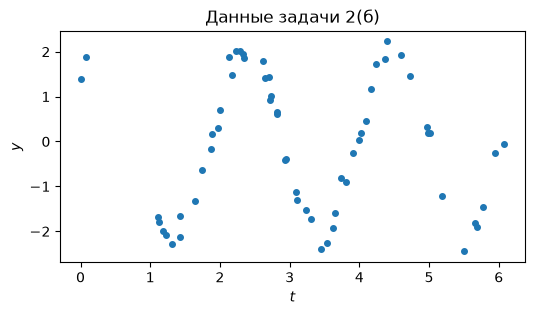

In [11]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_


**Модель B.** $\varphi_B(t;x)=x_1\sin\omega t+x_2\cos\omega t$ 

линейна по $x$ (
$\omega$ известна), поэтому $f(x)=\tfrac12\|Ax-y\|^2$ с $A_{i}=(\sin\omega t_i,\cos\omega t_i)$
— это квадратичная форма с $Q=A^\top A\succeq0$ (матрица Грама).

Класс:
безусловная QP, выпуклая (строго выпуклая при $\mathrm{rank}(A)=2$)


**Модель A.** $\varphi_A(t;x)=x_1\sin(x_2t+x_3)$ 

нелинейна по $x_2,x_3$ (внутри синуса), нет представления $\varphi_A=Ax$

Класс: безусловная нелинейная NLP (нелинейный МНК).

Невыпукла: из периодичности $\sin(\theta+2\pi)=\sin\theta$ получаем
$f(x_1,x_2,x_3+2\pi)=f(x_1,x_2,x_3)$ для любых $x$

Из $\sin(\theta+\pi)=-\sin\theta$
получаем $f(-x_1,x_2,x_3+\pi)=f(x_1,x_2,x_3)$

Значит,
если $x^*$ — глобальный минимум, бесконечно много других точек
($x_3^*+2\pi k$, а также их зеркальные ) тоже глобальные минимумы.
Между такими минимумами $f$ не остаётся на минимальном уровне, значит хорда между минимумами не лежит на их
уровне — нарушение определения выпуклости.

**Мультистарт (пункт 2)**

In [12]:
# ваш код
def fA(x):
    r = x[0]*np.sin(x[1]*t + x[2]) - y
    return 0.5*np.sum(r**2)

def fB(x):
    r = x[0]*np.sin(omega*t) + x[1]*np.cos(omega*t) - y
    return 0.5*np.sum(r**2)

In [13]:
resultsA = [minimize(fA, s, method="BFGS") for s in starts]
resultsB = [minimize(fB, s[:2], method="BFGS") for s in starts]  

fA_vals = np.array([r.fun for r in resultsA])
fB_vals = np.array([r.fun for r in resultsB])

In [14]:
print("Модель A")
print(fA_vals.round(4))
print("min:", fA_vals.min().round(4))
print()
print("Модель B")
print(fB_vals.round(4))
print("min:", fB_vals.min().round(4))

Модель A
[ 1.1393 63.8249  1.1393  1.1393  1.1393 61.4973 61.4973 64.2518  1.1393
 63.8249  1.1393  1.1393 61.4973  1.1393 64.2518  1.1393 61.6882  1.1393
 61.4973  1.1393]
min: 1.1393

Модель B
[1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408
 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408]
min: 1.1408


In [15]:
tol = 1e-4
fracA = np.mean(fA_vals <= fA_vals.min() + tol)
fracB = np.mean(fB_vals <= fB_vals.min() + tol)
print()
print(f"Доля стартов A, пришедших к наименьшему f: {fracA:.0%}")
print(f"Доля стартов B, пришедших к наименьшему f: {fracB:.0%}")



Доля стартов A, пришедших к наименьшему f: 55%
Доля стартов B, пришедших к наименьшему f: 100%


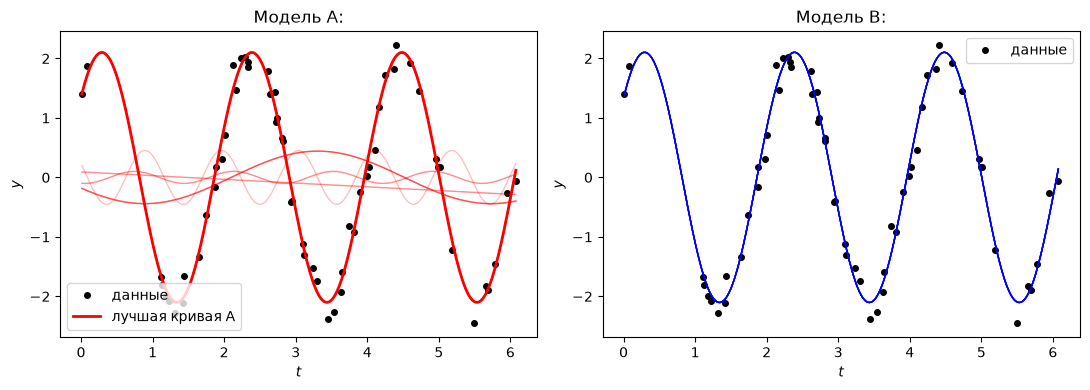

In [16]:
tt = np.linspace(t.min(), t.max(), 300)
best_A = resultsA[np.argmin(fA_vals)].x
best_B = resultsB[np.argmin(fB_vals)].x

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(t, y, "o", ms=4, color="black", label="данные")
for r in resultsA:
    xa = r.x
    ax.plot(tt, xa[0]*np.sin(xa[1]*tt + xa[2]), color="red", alpha=0.25, lw=1)
ax.plot(tt, best_A[0]*np.sin(best_A[1]*tt + best_A[2]), color="red", lw=2,
         label="лучшая кривая A")
ax.set(title="Модель A:", xlabel="$t$", ylabel="$y$")
ax.legend()

ax = axes[1]
ax.plot(t, y, "o", ms=4, color="black", label="данные")
for r in resultsB:
    xb = r.x
    ax.plot(tt, xb[0]*np.sin(omega*tt) + xb[1]*np.cos(omega*tt), color="blue", alpha=0.25, lw=1)
ax.set(title="Модель B:", xlabel="$t$", ylabel="$y$")
ax.legend()

plt.tight_layout()
plt.show()

B: все 20 стартов сходятся к $f_B\approx1{,}141$ 

A: только 55% стартов находят $f_A\approx1{,}139$, остальные застревают
в локальных минимумах, что подтверждает невыпуклость A

**Объяснение (пункт 3)**

**Ответ:** 

1) Наши задачи безусловные, значит градиент функции в минимуме должен быть равен нулю — это необходимое условие минимума. Для выпуклой функции B это условие ещё и достаточное, поэтому все старты сходятся к одному и тому же глобальному минимуму. Для невыпуклой функции A это условие только необходимое, но не достаточное: стационарных точек несколько, поэтому часть стартов приводит в локальные минимумы, а не в глобальный.

2) **Как из решения B получить амплитуду и фазу для модели A?**

Решение B даёт коэффициенты $x_1^B,x_2^B$ при $\sin(\omega t)$ и $\cos(\omega t)$ — это декартовы координаты. Переходя к полярным, получаем амплитуду и фазу модели A:

$x_1^A=\sqrt{(x_1^B)^2+(x_2^B)^2}, \qquad x_3^A=\operatorname{atan2}(x_2^B,x_1^B), \qquad x_2^A=\omega$


3) **Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?**

Модель A содержит модель B как частный случай (при $x_2^A=\omega$), поэтому

$$\min_x f_A(x) \le \min_x f_B(x)$$

всегда. Строго меньше — потому что данные зашумлены, и лишний параметр (частота) в A позволяет чуть точнее подстроиться под конкретный шум.

4) **Почему это не делает A «лучшей».** Это переобучение, а не улучшение модели истинная частота известна и равна $\omega$, а не подбирается. Сходимость к глобальному минимуму лишь у 55% стартов против 100% у B.


## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:** 

Условие оптимальности проекции ($f(x)=\tfrac12\|x-p\|^2$, $\nabla f(x^*)=x^*-p$):

$(y-x^*)^\top(x^*-p)\ge 0 \quad \forall y\in\Omega$

Для $x^*=P(p)$ берём пробную точку $y=q^*=P(q)$:
$(q^*-x^*)^\top(x^*-p)\ge 0 \qquad (1)$

Для $q^*=P(q)$ берём пробную точку $y=x^*=P(p)$:
$(x^*-q^*)^\top(q^*-q)\ge 0 \qquad (2)$

Складываем (1)+(2) и раскрываем скобки:

$\|x^*-q^*\|^2 \le (x^*-q^*)^\top(p-q)$

По неравенству Коши–Буняковского правая часть $\le \|x^*-q^*\|\,\|p-q\|$, значит

$\|x^*-q^*\|^2 \le \|x^*-q^*\|\,\|p-q\| \;\Longrightarrow\; \|P(p)-P(q)\| \le \|p-q\|$

In [17]:
# ваш код

rng = np.random.default_rng(0)
n, N = 5, 1000
p = rng.normal(size=(N, n)) * 3
q = rng.normal(size=(N, n)) * 3

#проекция на шар
def P_ball(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(1, norms)

lhs_ball = np.linalg.norm(P_ball(p) - P_ball(q), axis=1)
rhs = np.linalg.norm(p - q, axis=1)
print("Шар: max(||P(p)-P(q)|| - ||p-q||) =", np.max(lhs_ball - rhs)) 

#проекция на куб
lhs_cube = np.linalg.norm(np.clip(p, -1, 1) - np.clip(q, -1, 1), axis=1)
print("Куб: max(||P(p)-P(q)|| - ||p-q||) =", np.max(lhs_cube - rhs))  

Шар: max(||P(p)-P(q)|| - ||p-q||) = -1.385484156442358
Куб: max(||P(p)-P(q)|| - ||p-q||) = -0.17421352036021376


на 1000 случайных парах точек для обеих проекций разница $\|P(p)-P(q)\|-\|p-q\|$ всюду отрицательна ( $-1.39$ и $-0.17$) 

неравенство $\|P(p)-P(q)\|\le\|p-q\|$ выполняется численно, что соответсвует нашему докаательству


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).